Exploratory notebook for cleaning and processing data

In [6]:
#replacement cols
clean_columns = [
    'dr_no',             # DR_NO
    'date_rptd',         # Date Rptd
    'date_occ',          # DATE OCC
    'time_occ',          # TIME OCC
    'area',              # AREA
    'area_name',         # AREA NAME
    'rpt_dist_no',       # Rpt Dist No
    'part_1_2',          # Part 1-2
    'crm_cd',            # Crm Cd
    'crm_cd_desc',       # Crm Cd Desc
    'mocodes',           # Mocodes
    'vict_age',          # Vict Age
    'vict_sex',          # Vict Sex
    'vict_descent',      # Vict Descent
    'premis_cd',         # Premis Cd
    'premis_desc',       # Premis Desc
    'weapon_used_cd',    # Weapon Used Cd
    'weapon_desc',       # Weapon Desc
    'status',            # Status
    'status_desc',       # Status Desc
    'crm_cd_1',          # Crm Cd 1
    'crm_cd_2',          # Crm Cd 2
    'crm_cd_3',          # Crm Cd 3
    'crm_cd_4',          # Crm Cd 4
    'location',          # LOCATION
    'cross_street',      # Cross Street
    'lat',               # LAT
    'lon'                # LON
]

In [7]:
import pandas as pd
df = pd.read_csv('Crime_Data_from_2020_to_Present.csv')
#replace column names with column names that are easier to use and more consistent
df.columns = clean_columns

#clean up df
#drop entries that were recorded twice
df.drop_duplicates(inplace=True, subset = df.columns.tolist().remove('dr_no'))

#useless or redundant
df.drop(['part_1_2', 'crm_cd_1'], axis =1, inplace=True)

#drop crimes with missing crime type
df.dropna(subset = ['crm_cd'], inplace=True)

#convert dates to datetime
df['date_occ'] = pd.to_datetime(df['date_occ'], format="%m/%d/%Y %H:%M:%S %p")
df['date_rptd'] = pd.to_datetime(df['date_rptd'], format="%m/%d/%Y %H:%M:%S %p")

#convert time occured to an actual time
df['time_occ'] = pd.to_datetime((df['time_occ'] // 100 ).astype('string') + ':' + (df['time_occ'] % 100 ).astype('string'), format="%H:%M")

#drop nonsensical values
df = df.loc[(df.vict_age > 0) & (df.date_rptd > df.date_occ)]

In [8]:
df.head()


,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,crm_cd,crm_cd_desc,mocodes,...,weapon_desc,status,status_desc,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
0,211507896,2021-04-11 12:00:00,2020-11-07 12:00:00,1900-01-01 08:45:00,15,N Hollywood,1502,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020-10-21 12:00:00,2020-10-18 12:00:00,1900-01-01 18:45:00,15,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10 12:00:00,2020-10-30 12:00:00,1900-01-01 12:40:00,9,Van Nuys,933,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
4,201418201,2020-10-03 12:00:00,2020-09-29 12:00:00,1900-01-01 18:30:00,14,Pacific,1454,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,NaN,IC,Invest Cont,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
5,240412063,2024-12-11 12:00:00,2020-11-11 12:00:00,1900-01-01 12:10:00,4,Hollenbeck,429,354,THEFT OF IDENTITY,0100,...,NaN,IC,Invest Cont,NaN,NaN,NaN,5300 CRONUS ST,NaN,34.0830,-118.1678


### Make Example Viz (2)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

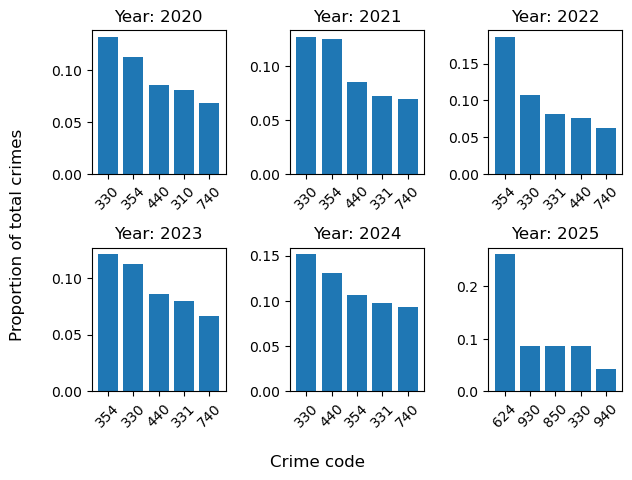

In [21]:
#get total of each crime for each year, pick the 5 most common for each year and find out what percent of the total they were for that year
years = pd.crosstab(df.date_occ.dt.year, df.crm_cd).reset_index()
transformed = years.melt(id_vars='date_occ', var_name='crm_cd', value_name='count')
totals = transformed.groupby('date_occ')['count'].sum()

idx=[]
for year in transformed.date_occ.unique():
    temp = transformed.loc[transformed.date_occ == year]
    idx += (temp.sort_values('count', ascending=False)[:5].index.tolist())
for_plotting = transformed.iloc[idx].reset_index(drop=True)
for_plotting['count'] = for_plotting['count'] / for_plotting['date_occ'].map(totals)

#plot
fig, ax = plt.subplots(2, 3)
row = col = 0

#make barplots
for y in range(2020, 2026):
    data = for_plotting.loc[for_plotting.date_occ == y]
    ax[row, col].bar(data.crm_cd.astype(str), data['count'])
    ax[row, col].set_title(f'Year: {y}')
    ax[row, col].tick_params(axis='x', labelrotation=45)
    col+=1
    if col>2:
        row+=1
        col=0
fig.supxlabel('Crime code')
fig.supylabel('Proportion of total crimes')
fig.tight_layout()